In [10]:
##%pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

In [11]:
import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.11.11
qiskit: 2.3.1
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.46.1


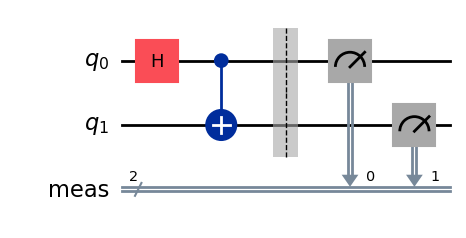

In [12]:
# --- Build the Bell circuit (phi-plus) ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()  # creates a classical register named "meas"

bell.draw("mpl")

In [13]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

In [ ]:
# Run this ONCE to save your credentials (they persist outside this repo, e.g.
# ~/.qiskit/qiskit-ibm-runtime.json). After that, delete this save_account block —
# QiskitRuntimeService() below will keep loading the saved account.
#
# getpass prompts for the token at runtime so it is never typed or stored in
# this notebook file (and therefore never ends up in git history).
import getpass

QiskitRuntimeService.save_account(
    token=getpass.getpass("IBM Quantum token: "),
    instance="open-instance",
    channel="ibm_quantum_platform",
    overwrite=True,
    set_as_default=True,
)

# Load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_fez")
print(backend.name)

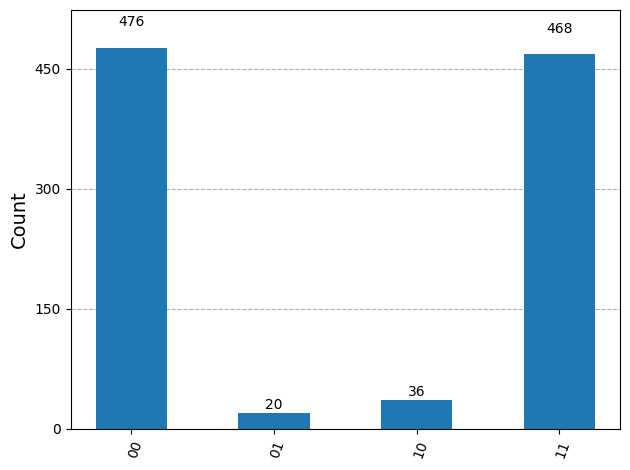

In [ ]:
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)

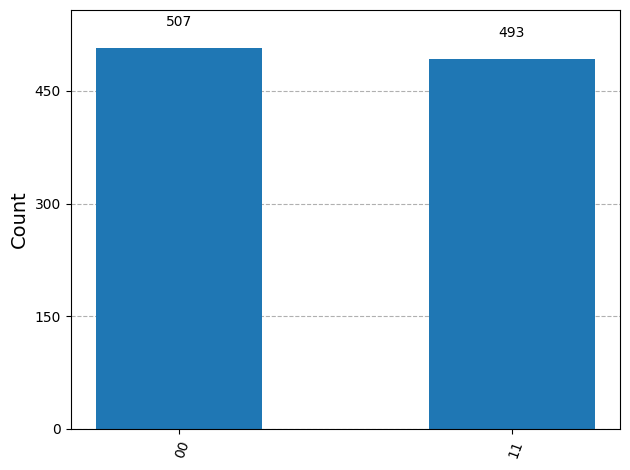

In [ ]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend, shots=1000)

plot_histogram(counts)